# Evaluating performance of variant growth rate inference of FGA and GARW models

## Notebook Overview

### Objectives
* Define a way to compare model Rt inference with simulated observations 
* Zoom-in on on a well-performing window and ones that contradict biological intuition despite decent performance metrics, as well as those that just perform poorly
* Compare ability of FGA and GARW models to estimate variant growth rates across entire simulation

### Methods

**Growth Rate Transformation Framework:**
* Load epidemic growth rates ($r_{\text{model},v}(t)$) inferred alongside effective reproductive numbers ($R_v(t)$) by `evofr`, if not available, infer using the Euler-Lokta equation, the gamma-distributed generation times, and the `evofr` inferred $R_v(t)$ values
* Calculate empirical growth rates ($r_{\text{data},v}(t)$) from variant-specific incidence data using log-difference of smoothed variant frequencies and case counts
* Add and apply consistent filtering criteria for variants to be included in growth rate analysis, including: minimum smoothed sequence count (10) and minimum variant frequency (0.01) to ensure reliable estimates
* Use univariate spline smoothing (s=1.0, order=3) to reduce noise in variant frequency data (or counts if desired)

**Performance Metrics:**
- **Pearson correlation**: Measures linear relationship between model and empirical growth rates
- **Mean Absolute Error (MAE)**: Quantifies average magnitude of prediction errors
- **Normalized MAE (nMAE)**: MAE divided by the largest $r_{\text{data},v}(t)$ in the window
- **Root Mean Square Error (RMSE)**: Penalizes larger errors more heavily
- **Overestimation rate**: Fraction of time points where $r_{\text{model},v}(t)$ overestimates $r_{\text{data},v}(t)$ by at least some tolerance threshold $\epsilon = 1e-3$
- **Sign disagreement rate**: Frequency of disagreement on growth direction (positive/negative)


### Results

**Individual Window Analysis:**
1. **Combined dynamics plots** (`plot_analysis_window_with_variant_counts`): Four-panel visualization showing variant frequencies, sampled sequences, fitness trajectories, and $R_v(t)$ estimates for specific training windows
2. **Growth rate comparison plots** (`plot_growth_rate_dynamics`): Direct comparison of $r_{\text{model}}$ vs $r_{\text{data}}$ with variant-specific trajectories and frequency-based filtering (note that smoothed frequencies shown are smoothed for calculations and not the model inferred values)

**Aggregate Performance Analysis:**
1. **Distribution plots**: Box plots comparing correlation, MAE, RMSE, and overestimation rates between FGA/GARW models across geographic regions
2. **Variant-level error tracking**: Scatter plots showing average MAE and overestimation rates for individual variants across all training windows, with outliers labeled
3. **Outlier identification**: Tables highlighting training windows with extreme performance metrics (lowest correlations, highest MAE values) averaged across all variants

**Deep-dive Investigations:**
* Detailed growth rate dynamics for windows with high overestimation rates (≥0.8) or high MAE values (≥0.15)
* Side-by-side comparisons of variant metrics between different regions and time periods

### Conclusion
* Overall, windows that perform poorly with MAE tend to have sparse sequences and or case counts over most of the training window
  * Sometimes, we see an artificial "hump" in the model inferred growth rates, perhaps an artifact of these models and how they're formulated?
  * Sometimes, models infer a pretty big jump in growth rates in a very short time window, even if the emperical data disagrees
* Overestimation rate is a more fuzzy metric, and more difficult to justify using, but it seems to be pretty good at flagging windows that may have artificial "humps" if we actually care about investigating the mechanisms underlying them a bit more -- but for the purpose of the paper, perhaps it's best to just focus on MAE going forward...
* GARW models seem to just do a bit better on this task when compared to FGA models on this simulated dataset

## Variant growth Rate Calculations and Comparrisons using Euler-Lotka Method

### Quick overview
The Euler-Lotka equation provides a way to calculate growth rates based on reproduction numbers and generation time distributions. This approach is particularly useful for infectious disease modeling as it connects the effective reproduction number (Rt) with the exponential growth rate (r).

In the Fixed Growth Advantage (FGA) model, each variant has its own multiplicative growth factor $\delta_v$ that scales a variant-agnostic effective reproduction number $R_t$:

$$R_v(t) = \delta_v \cdot R_t$$

The Growth Advantage Random Walk (GARW) model allows variant growth advantages to vary smoothly over time, with each variant's effective reproduction number following a random walk prior:

$$R_v(t) \sim \mathcal{N}(R_v(t-1), \sigma^2)$$

The Euler-Lotka equation establishes the relationship between the effective reproduction number ($R_v(t)$) and the exponential growth rate ($r_v(t)$) accounting for the generation time distribution. 

The equation looks like this:

$$ \int_{0}^{\infty} e^{-r\tau} R_0 g(\tau)\,d\tau = 1 $$

Where:
* $r$ is the epidemic growth rate
* $\tau$ is a possible generation time
* $R_0 g(\tau)\,d\tau$ can be interpreted as the average numebr of **new** infections caused by our initial host at generation time $\tau$ (i.e., think between a time $t$ and $t + \tau$)
* $e^{-r\tau}$ is the "discount" of new cases accumulated during the generation time (keeps us from double counting infections I believe)


### Derivation of $r_{\text{model},v}(t_i)$ for our use case
Notice that this is actually $M_g(-r)$: MGF for $g(\tau)$, evaluated at $-r$, and then multiplied by $R_0$.

So we can now re-write this as $$R_0 \cdot M_g(-r) = 1$$

$$R_0 = \frac{1}{M_g(-r)} $$

And for our $R_t$:

$$R_t = \frac{1}{M_g(-r)} $$

We have been using a gamma distribution with shape parameter $\alpha$ and scale parameter $\theta$ for generation time distribution. 
The MGF for this gamma distribution is:

$$M_g(x) = (1 - x \theta)^{-\alpha} \text{ for } x\theta < 1 $$

Evaluating for $-r`: 

$$ M_g(-r) = (1 + r \theta)^{-k\alpha}$$

And since $R_t = \frac{1}{M_g(-r)}$, we have: 

$$R_t = (1 + r\theta)^{\alpha} $$

This is essentially where Marlin's paper stops with the Gamma case...now, we'd like to get the variant growth rate $r$ -- so let's solve for that:

$$R^{1/\alpha}_t = 1 + r\theta $$

$$r = \frac{R^{1/\alpha} - 1}{\theta} $$

So now we have a relationship between $r$ and model inferred $R_t$ (let's add the t to $r$ now...)

$$r_{\text{model}}(t) = \frac{R_t^{1/\alpha} - 1}{\theta}$$

### Derivation of $r_{\text{data},v}(t_i)$ for our use case
We can then let $C_{d}(t_i)$ be the number of observed cases in location $d$ at time $t_i$.

We can calculate a smoothed growth rate estimate for the observed case counts:

$$r_{\text{data}}(t_i) = \frac{\ln(C_{d}(t_i)) - \ln(C_{d}(t_i - 1))}{\Delta t_i}  $$

If we'd like this metric to be variant-specific, we have to estimate the number of counts attributable to a variant $v$:

$$C_{v,d}(t_i) = C_d(t_i) \cdot f_{v,d}(t_i) $$

$$r_{\text{data},v}(t_i) = \frac{\ln(C_{v,d}(t_i)) - \ln(C_{v,d}(t_i - 1))}{\Delta t_i}  $$


### Big Idea

* With these two metrics in hand, we can more rigorously compare model $R_t$ inference to the variant-specific growth rates in a deme
* This allows us to side-step the mis-match of looking at the derivative of raw variant counts and comparing them to the value of Rt
* We can now calculate pearson correlation between these two things and have a clear idea of how well models are doing
* Training windows with few and/or sparse case counts may generate pretty noisy $r_{\text{data},v}(t_i)$ however
* Sequence and case counts are reported weekly, where model inference is daily, so we'll have to consolidate this a bit... we could just focus on reporting dates and ignore inference on the six days in between each one... Or possibly interpolate the rest of the week with whatever the value is for that week, etc.
* Univariate spline smoothing on variant count data since these can be a lot nosier than cases -- but maybe these should be smoothed too?

## Package Imports

In [1]:
# General imports
import glob
import json
import random
import sys
sys.path.append('..')

# Data handling and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Antigen tools
from antigentools.plot import (
    plot_antigenic_space_by_clade, 
    plot_analysis_window_with_variant_counts,
    plot_growth_rate_dynamics,
    plot_observed_dynamics
)
from antigentools.utils import (
    get_deme_stats,
    get_outliers,
)
from antigentools.analysis import (
    calculate_variant_mae,
    evaluate_growth_rate_performance,
    get_filtered_growth_rates_df
)

# Import publication styling
from antigentools.publication_style import style_figure_for_publication
import matplotlib.gridspec as gridspec


# Static variables for consistent growth rate filtering across the notebook
CONNECT_GAPS = True # Whether to connect gaps in the growth rate data when plotting
MIN_SEGMENT_LENGTH = 3 # Minimum segment length to trust growth rate calculations
MIN_SEQUENCE_COUNT = 10  # Minimum smoothed sequence count to continue with growth rate calculations
MIN_VARIANT_FREQUENCY = 0.01  # Minimum variant frequency to trust growth rate to consider growth rate calculations
MIN_VARIANT_INCIDENCE = 50  # Minimum variant incidence to consider growth rate calculations 
EPSILON = 1e-3  # Tolerance threshold for overestimation rate calculations

# NEW: Sequence count threshold filter (set to None to disable filtering)
MIN_TOTAL_SEQUENCES = 300  # e.g., 750 to require at least 750 total sequences per window
CONVERGENCE_THRESHOLD = 0.5  # Threshold for convergence diagnostics

print(f"Analysis configuration:")
print(f"  MIN_TOTAL_SEQUENCES filter: {MIN_TOTAL_SEQUENCES}")
print(f"  MIN_SEQUENCE_COUNT per variant: {MIN_SEQUENCE_COUNT}")
print(f"  MIN_VARIANT_FREQUENCY: {MIN_VARIANT_FREQUENCY}")
print(f"  MIN_VARIANT_INCIDENCE: {MIN_VARIANT_INCIDENCE}")
print(f"  EPSILON (overestimation tolerance): {EPSILON}")

Analysis configuration:
  MIN_TOTAL_SEQUENCES filter: 300
  MIN_SEQUENCE_COUNT per variant: 10
  MIN_VARIANT_FREQUENCY: 0.01
  MIN_VARIANT_INCIDENCE: 50
  EPSILON (overestimation tolerance): 0.001


/Users/zo/miniforge3/envs/antigen/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load files and setup analysis

In [2]:
# Original flu-final build (kept for reproducibility when its files are present).
build_flu_final = "flu-final"
# Round-1 review: representative run. Its data was staged at the batch root, but its
# results keep the nested <config>__run_N pipeline layout.
build_review_1 = "2026-07-04-reviewer-runs"
results_build_review_1 = "2026-07-04-reviewer-runs/nonEpitopeAcceptance_0.25_epitopeAcceptance_0.75__run_14"
build = build_review_1
results_build = results_build_review_1

truth_set_dir = f"../data/{build}/time-stamped/truth/"
truth_seqs_df = pd.read_csv(f"{truth_set_dir}/seq_counts.tsv", sep="\t")
truth_cases_df = pd.read_csv(f"{truth_set_dir}/case_counts.tsv", sep="\t")

In [3]:
print(truth_seqs_df.head())
print(truth_cases_df.head())

         date country  variant  sequences
0  2024-12-08   north        1          2
1  2024-12-08   north        2          1
2  2024-12-15   north        0          2
3  2024-12-15   north        1          5
4  2024-12-15   south        0          1
         date  country    cases
0  2025-01-05    north  1306973
1  2025-01-05    south     1978
2  2025-01-05  tropics    16760
3  2025-01-11    north  1380202
4  2025-01-11    south     2284


In [4]:
 # Small fonts for dense plots
small_fonts = {
    'title_fontsize': 14,
    'label_fontsize': 12,
    'tick_labelsize': 10,
    'legend_fontsize': 10,
    'legend_title_fontsize': 12
 }

  # Large fonts for presentations
presentation_fonts = {
    'title_fontsize': 28,
    'label_fontsize': 20,
    'tick_labelsize': 16,
    'legend_fontsize': 16,
    'legend_title_fontsize': 18
}

  # Default/medium fonts
default_fonts = {
    'title_fontsize': 18,
    'label_fontsize': 14,
    'tick_labelsize': 12,
    'legend_fontsize': 12,
    'legend_title_fontsize': 14
}

In [5]:
# Color palette for the different locations
deme_palette = {
    "tropics": "#3498db",  # Softer blue
    "north": "#e67e22",    # Warmer orange 
    "south": "#2ecc71"     # More vibrant green
}

In [6]:
import os
color_map_path = f"../data/{build}/auspice/variant_color_map.tsv"
if os.path.exists(color_map_path):
    color_map_df = pd.read_csv(color_map_path, sep="\t")
else:
    # No saved color map for this build; derive the variant list from the tips
    # (HEX_CODE is overwritten with a seaborn deep palette in the next cell).
    _variants = sorted(pd.read_csv(f"../data/{build}/tips_with_variants.tsv", sep="\t")["variant_ag"].unique())
    color_map_df = pd.DataFrame({"TRAIT_VALUE": _variants, "HEX_CODE": None})
color_map_df.head()

,TRAIT_VALUE,HEX_CODE
0,0,None
1,1,None
2,2,None
3,3,None
4,4,None


In [7]:
# Change color map to be the deep palette from seaborn
deep_palette = sns.color_palette("deep", n_colors=len(color_map_df))
color_map_df['HEX_CODE'] = deep_palette.as_hex()
color_map_df.head()

,TRAIT_VALUE,HEX_CODE
0,0,#4c72b0
1,1,#dd8452
2,2,#55a868
3,3,#c44e52
4,4,#8172b3


In [8]:
# Create a color map dictionary from the color_map_df
color_map = dict(zip(color_map_df['TRAIT_VALUE'], color_map_df['HEX_CODE']))
# String color map for plotting
color_map_str = {str(k): v for k, v in color_map.items()}
print(f"Created color map with {len(color_map)} entries")
print(f"Sample: {list(color_map.items())[:5]}")

Created color map with 30 entries
Sample: [(0, '#4c72b0'), (1, '#dd8452'), (2, '#55a868'), (3, '#c44e52'), (4, '#8172b3')]


In [9]:
tips_path = f"../data/{build}/tips_with_variants.tsv"
tips_df = pd.read_csv(tips_path, sep="\t")
tips_df.head()

,name,year,trunk,tip,mark,location,layout,nucleotideSequence,ag1,ag2,...,highEpitopeMutationCount,fitness,averageInfectionRisk,probSusceptible,demeSeasonality,country,variant_ag,variant_tsne,variant_phylo,year_bin
0,1e2cf87,-0.0050,0,1,0,0,3966.0,ATGAAGACTATCATTGCTTTGAGCTACATTCTATGTCTGGTTTTCG...,21.1798,5.9966,...,0,0.7042,0.6299,0.9721,1.15,north,2,2,2,-1
1,1849c17c,-0.0059,0,1,0,0,3381.0,ATGAAGACTATCATTGCTTTGAGCTACATTCTATGTCTGGTTTTCG...,20.1883,4.8673,...,0,0.6323,0.5656,0.9721,1.15,north,1,1,2,-1
2,5cd008ed,-0.0279,0,1,0,0,832.0,ATGAAGACTATCATTGCTTTGAGCTACATTCTATGTCTGGTTTTCG...,18.9818,4.8758,...,0,0.5815,0.5202,0.9721,1.15,north,0,0,0,-1
3,6dd8a74c,-0.0238,0,1,0,0,109.0,ATGAAGACTATCATTGCTTTGAGCTACATTCTATGTCTGGTTTTCG...,19.8617,5.0527,...,0,0.6239,0.5581,0.9721,1.15,north,1,0,0,-1
4,50a0da58,-0.0076,0,1,0,0,1002.0,ATGAAGACTATCATTGCTTTGAGCTACATTCTATGTCTGGTTTTCG...,20.2179,5.2691,...,0,0.6397,0.5722,0.9721,1.15,north,1,0,0,-1


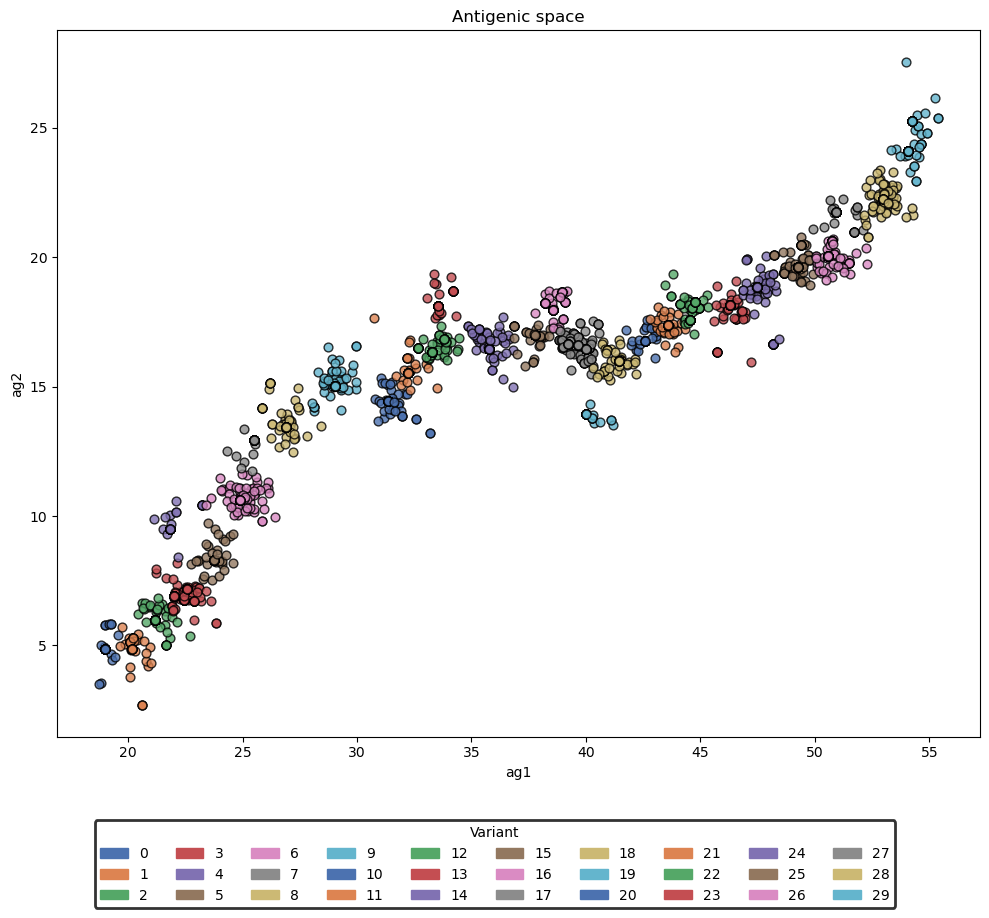

In [10]:
plot_antigenic_space_by_clade(
    tips_df, 
    color_map=color_map, 
    variant_col='variant_ag',
    figsize=(10, 8)
)

In [11]:
window_growth_rates_scores_path = f"../results/{results_build}/growth_rate_scores.tsv"
variant_growth_rates_scores_path = f"../results/{results_build}/variant_growth_rates.tsv"
convergence_diagnostics_path = f"../results/{results_build}/vi_convergence_diagnostics.tsv"

# Load growth rate scores
window_growth_rate_errors_df = pd.read_csv(window_growth_rates_scores_path, sep="\t")
variant_growth_rate_errors_df = pd.read_csv(variant_growth_rates_scores_path, sep="\t")
convergence_diagnostics_df = pd.read_csv(convergence_diagnostics_path, sep="\t")

In [12]:
# Take a look at window growth rates
window_growth_rate_errors_df.head()

,pivot_date,model,location,correlation,mae,mse,rmse,r2,n_seqs,n_cases,seq_entropy,case_entropy,seq_entropy_norm,case_entropy_norm
0,2025-04-01,FGA,north,0.537553,0.159469,0.051792,0.227579,-56.328236,4188,8822831,3.448747,3.288701,0.843738,0.888732
1,2025-10-01,FGA,north,0.463663,0.168329,0.038502,0.196219,-116.537584,4240,8952811,3.532666,3.390575,0.734846,0.641498
2,2028-04-01,FGA,north,-0.937274,0.034843,0.001859,0.043116,-14.423085,652,1523224,4.129815,4.218972,0.792754,0.740113
3,2028-10-01,FGA,north,0.677889,0.028520,0.001142,0.033788,-1.052015,1029,2365768,4.773196,4.851852,0.864152,0.851137
4,2029-04-01,FGA,north,-0.435492,0.134905,0.029059,0.170466,-21.583472,1711,3778298,4.298743,4.341615,0.792210,0.757974


## Variant-specific growth rate errors

In [13]:
print(f"Number of variant growth rate error entries: {len(variant_growth_rate_errors_df)}")
variant_growth_rate_errors_df.head()

Number of variant growth rate error entries: 464


,variant,pivot_date,model,location,mae,mse,normalized_mae,max_r_data,correlation,r2,n_points,total_sequences,total_smoothed_sequences,mean_variant_frequency,mean_smoothed_variant_frequency,max_variant_frequency,max_smoothed_variant_frequency,converged
0,0,2025-04-01,FGA,north,0.024248,0.000752,0.287340,0.084389,-0.398817,-0.447252,8,414.0,413.824772,0.135844,0.141616,0.193959,0.242101,False
1,1,2025-04-01,FGA,north,0.049555,0.003459,0.677895,0.073102,-0.808564,-7.008027,11,1956.0,1955.842521,0.639951,0.637443,0.732601,0.696702,False
2,2,2025-04-01,FGA,north,0.367726,0.137245,7.557858,0.048655,-0.859170,-205.882693,11,459.0,458.851073,0.239275,0.236174,0.466667,0.404918,False
3,0,2025-10-01,FGA,north,0.061489,0.004375,0.958697,0.064138,-0.998801,-14.651011,7,404.0,403.939668,0.140673,0.152410,0.193959,0.191437,False
4,1,2025-10-01,FGA,north,0.114925,0.013916,1.707451,0.067308,-0.958821,-35.102976,12,1973.0,1973.007358,0.654082,0.676707,0.809524,0.719050,False


In [14]:
# Only keep converged entries
variant_growth_rate_errors_df = variant_growth_rate_errors_df[variant_growth_rate_errors_df['converged'] == True]
print(f"Number of converged variant growth rate error entries: {len(variant_growth_rate_errors_df)}")

Number of converged variant growth rate error entries: 235


### MAE

In [15]:
variant_growth_rate_errors_df.head()

,variant,pivot_date,model,location,mae,mse,normalized_mae,max_r_data,correlation,r2,n_points,total_sequences,total_smoothed_sequences,mean_variant_frequency,mean_smoothed_variant_frequency,max_variant_frequency,max_smoothed_variant_frequency,converged
22,8,2031-10-01,FGA,north,0.003757,0.000019,0.100587,0.037351,0.985855,0.952583,19,424.0,424.041869,0.993016,0.983148,1.000000,1.000000,True
23,8,2032-04-01,FGA,north,0.002193,0.000009,0.098050,0.022364,0.846716,0.470487,4,76.0,75.997794,1.000000,0.993310,1.000000,0.995000,True
24,9,2032-04-01,FGA,north,0.005151,0.000036,0.070939,0.072614,0.995720,0.988502,23,6146.0,6146.000543,0.905661,0.895988,1.000000,0.984318,True
25,10,2032-04-01,FGA,north,0.006451,0.000064,0.071214,0.090588,0.989602,0.964926,10,250.0,250.051698,0.077043,0.081621,0.182353,0.152248,True
31,12,2036-10-01,FGA,north,0.027256,0.001135,0.375272,0.072630,0.992055,0.476533,21,2834.0,2833.960031,0.549126,0.548792,0.890909,0.868620,True


In [16]:
# Calculate log(MAE) and add as new column
variant_growth_rate_errors_df['log_mae'] = np.log(variant_growth_rate_errors_df['mae'] + 1e-6)
variant_growth_rate_errors_df['log_mse'] = np.log(variant_growth_rate_errors_df['mse'] + 1e-6)

## Boxplot of log(MAE) of growth rate errors

In [17]:
save_path = '../../antigen-tex/reviews/round1/figures/figureS3_growth_rates_log_error_boxplot'

Figure saved to ../../antigen-tex/reviews/round1/figures/figureS3_growth_rates_log_error_boxplot.pdf and ../../antigen-tex/reviews/round1/figures/figureS3_growth_rates_log_error_boxplot.png


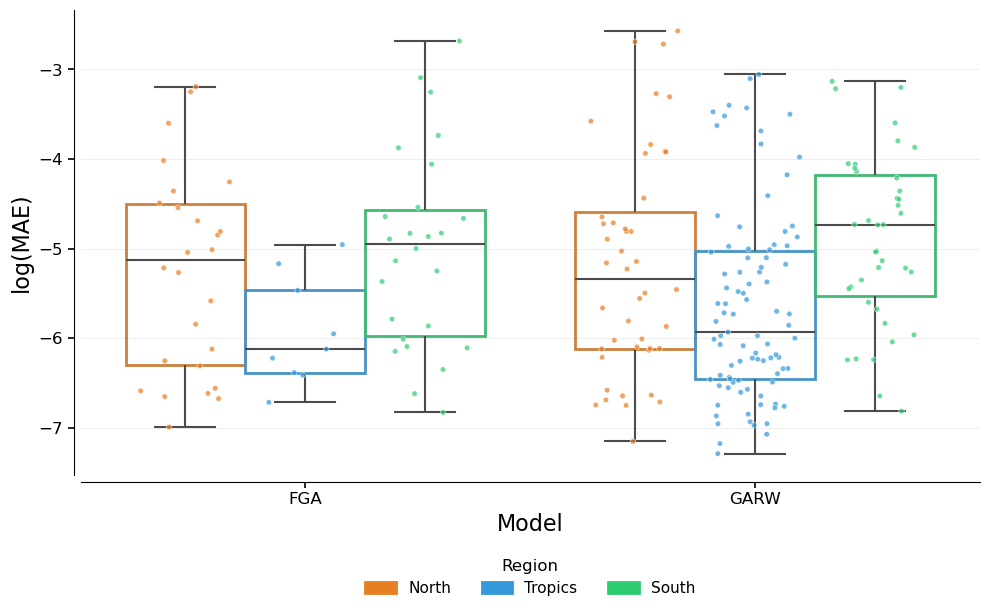

In [18]:
# Enhanced boxplot of log(MAE) by model and location with publication styling
fig, ax = plt.subplots(figsize=(10, 6))

# Create boxplot with refined styling
boxplot = sns.boxplot(
    data=variant_growth_rate_errors_df,
    x='model',
    y='log_mae',
    hue='location',
    hue_order=['north', 'tropics', 'south'],
    palette=deme_palette,
    showfliers=False,
    ax=ax,
    linewidth=1.5,
    fliersize=0
)

# Convert boxplots to outlined style for cleaner look
for patch in boxplot.patches:
    # Get the current face color for edge color
    edge_color = patch.get_facecolor()
    # Make boxes transparent with colored edges
    patch.set_facecolor('none')
    patch.set_edgecolor(edge_color)
    patch.set_linewidth(2)

# Style the boxplot lines (whiskers, medians, etc.)
plt.setp(boxplot.lines, linewidth=1.5)

# Add refined stripplot overlay
sns.stripplot(
    data=variant_growth_rate_errors_df,
    x='model',
    y='log_mae',
    hue='location',
    hue_order=['north', 'tropics', 'south'],
    palette=deme_palette,
    dodge=True,
    jitter=0.3,  # Reduced jitter for cleaner look
    size=4,      # Slightly smaller points
    alpha=0.7,   # Slightly more transparent
    edgecolor='white',
    linewidth=0.5,
    legend=False,
    ax=ax
)

# Publication-style labels and formatting
ax.set_xlabel('Model', fontsize=16)
ax.set_ylabel('log(MAE)', fontsize=16)

# Enhanced tick formatting
ax.tick_params(axis='both', which='major', labelsize=12, width=1.2, length=4)
ax.tick_params(axis='both', which='minor', width=1, length=2)

# Create custom legend
legend_elements = []
for location in ['north', 'tropics', 'south']:
    from matplotlib.patches import Patch
    patch = Patch(facecolor=deme_palette[location], 
                 edgecolor=deme_palette[location],
                 linewidth=2,
                 label=location.capitalize())
    legend_elements.append(patch)

# Position legend horizontally below the plot
legend = ax.legend(handles=legend_elements, 
                  title='Region', 
                  title_fontsize=12,
                  fontsize=11,
                  ncol=3,  # Horizontal orientation
                  loc='upper center',
                  bbox_to_anchor=(0.5, -0.15),  # Position below plot
                  frameon=False
                  )

# Enhanced despine and grid
sns.despine(ax=ax, offset=5, trim=False)
ax.grid(True, axis='y', alpha=0.3, linestyle='-', linewidth=0.5)
ax.set_axisbelow(True)

# Improved layout with better margins to accommodate legend below
plt.tight_layout()
plt.subplots_adjust(bottom=0.2)  # Add space for horizontal legend
# Save figure and show
plt.savefig(f'{save_path}.pdf', dpi=300, bbox_inches='tight')
plt.savefig(f'{save_path}.png', dpi=300, bbox_inches='tight')
print(f"Figure saved to {save_path}.pdf and {save_path}.png")
plt.show()

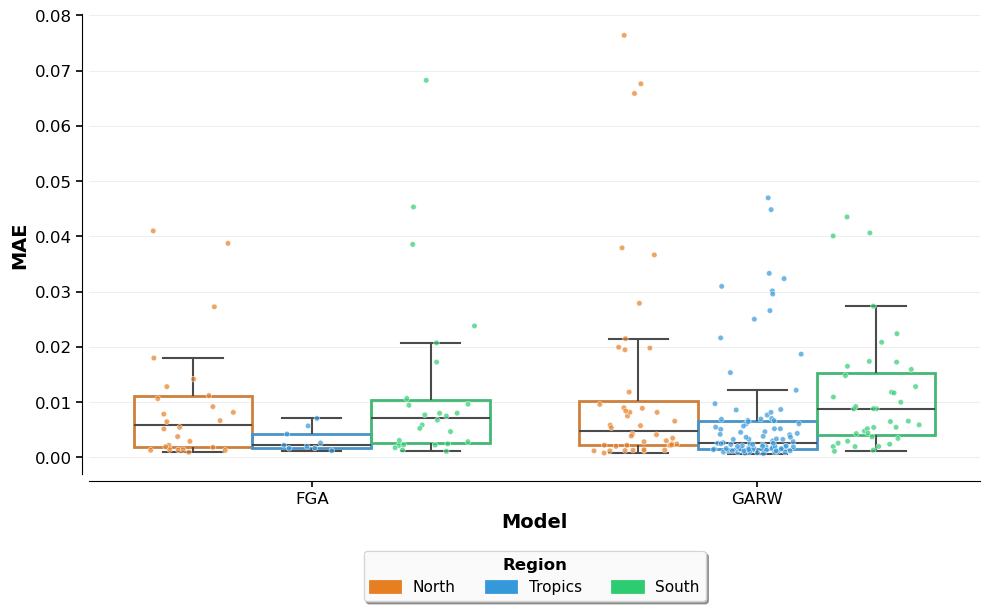

In [19]:
# Enhanced boxplot of log(MAE) by model and location with publication styling
fig, ax = plt.subplots(figsize=(10, 6))

# Create boxplot with refined styling
boxplot = sns.boxplot(
    data=variant_growth_rate_errors_df,
    x='model',
    y='mae',
    hue='location',
    hue_order=['north', 'tropics', 'south'],
    palette=deme_palette,
    showfliers=False,
    ax=ax,
    linewidth=1.5,
    fliersize=0
)

# Convert boxplots to outlined style for cleaner look
for patch in boxplot.patches:
    # Get the current face color for edge color
    edge_color = patch.get_facecolor()
    # Make boxes transparent with colored edges
    patch.set_facecolor('none')
    patch.set_edgecolor(edge_color)
    patch.set_linewidth(2)

# Style the boxplot lines (whiskers, medians, etc.)
plt.setp(boxplot.lines, linewidth=1.5)

# Add refined stripplot overlay
sns.stripplot(
    data=variant_growth_rate_errors_df,
    x='model',
    y='mae',
    hue='location',
    hue_order=['north', 'tropics', 'south'],
    palette=deme_palette,
    dodge=True,
    jitter=0.3,  # Reduced jitter for cleaner look
    size=4,      # Slightly smaller points
    alpha=0.7,   # Slightly more transparent
    edgecolor='white',
    linewidth=0.5,
    legend=False,
    ax=ax
)

# Enhanced threshold line styling
# ax.axhline(y=-4, color='#d32f2f', linestyle='--', linewidth=2, alpha=0.8, zorder=10)
# ax.text(-0.51, -3.85, 'Threshold', fontsize=10, color='#d32f2f', 
#         style='italic', ha='left', va='bottom')

# Publication-style labels and formatting
ax.set_xlabel('Model', fontsize=14, fontweight='bold')
ax.set_ylabel('MAE', fontsize=14, fontweight='bold')

# Enhanced tick formatting
ax.tick_params(axis='both', which='major', labelsize=12, width=1.2, length=4)
ax.tick_params(axis='both', which='minor', width=1, length=2)

# Create custom legend
legend_elements = []
for location in ['north', 'tropics', 'south']:
    from matplotlib.patches import Patch
    patch = Patch(facecolor=deme_palette[location], 
                 edgecolor=deme_palette[location],
                 linewidth=2,
                 label=location.capitalize())
    legend_elements.append(patch)

# Position legend horizontally below the plot
legend = ax.legend(handles=legend_elements, 
                  title='Region', 
                  title_fontsize=12,
                  fontsize=11,
                  ncol=3,  # Horizontal orientation
                  loc='upper center',
                  bbox_to_anchor=(0.5, -0.15),  # Position below plot
                  frameon=True,
                  framealpha=0.95,
                  edgecolor='lightgray',
                  fancybox=True,
                  shadow=True)
legend.get_title().set_fontweight('bold')

# Enhanced despine and grid
sns.despine(ax=ax, offset=5, trim=False)
ax.grid(True, axis='y', alpha=0.3, linestyle='-', linewidth=0.5)
ax.set_axisbelow(True)

# Improved layout with better margins to accommodate legend below
plt.tight_layout()
plt.subplots_adjust(bottom=0.2)  # Add space for horizontal legend
# Save figure and show
# plt.savefig(f'{save_path}.pdf', dpi=300, bbox_inches='tight')
# plt.savefig(f'{save_path}.png', dpi=300, bbox_inches='tight')
# print(f"Figure saved to {save_path}.pdf and {save_path}.png")
plt.show()

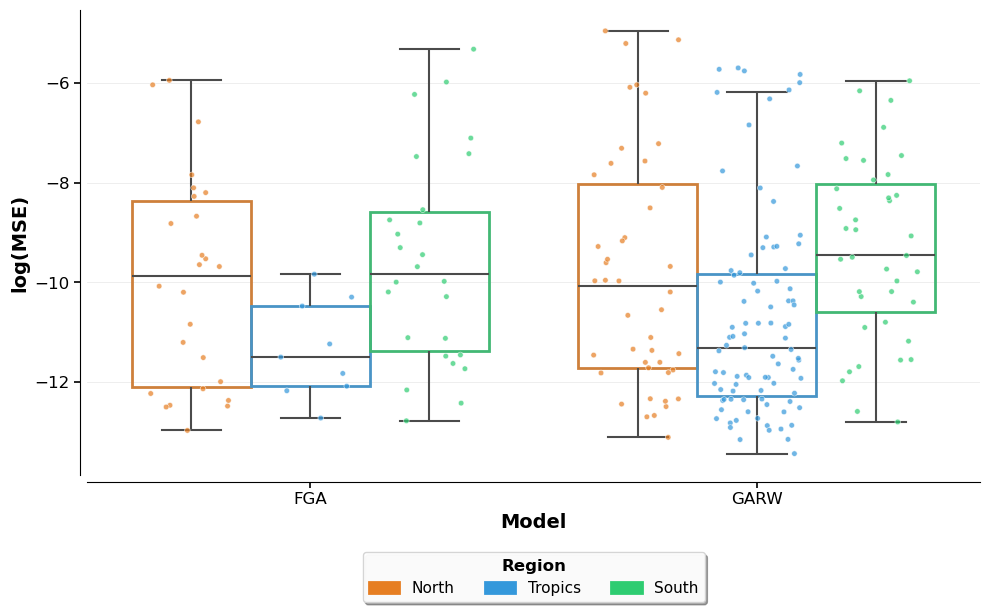

In [20]:
# Enhanced boxplot of log(MAE) by model and location with publication styling
fig, ax = plt.subplots(figsize=(10, 6))

# Create boxplot with refined styling
boxplot = sns.boxplot(
    data=variant_growth_rate_errors_df,
    x='model',
    y='log_mse',
    hue='location',
    hue_order=['north', 'tropics', 'south'],
    palette=deme_palette,
    showfliers=False,
    ax=ax,
    linewidth=1.5,
    fliersize=0
)

# Convert boxplots to outlined style for cleaner look
for patch in boxplot.patches:
    # Get the current face color for edge color
    edge_color = patch.get_facecolor()
    # Make boxes transparent with colored edges
    patch.set_facecolor('none')
    patch.set_edgecolor(edge_color)
    patch.set_linewidth(2)

# Style the boxplot lines (whiskers, medians, etc.)
plt.setp(boxplot.lines, linewidth=1.5)

# Add refined stripplot overlay
sns.stripplot(
    data=variant_growth_rate_errors_df,
    x='model',
    y='log_mse',
    hue='location',
    hue_order=['north', 'tropics', 'south'],
    palette=deme_palette,
    dodge=True,
    jitter=0.3,  # Reduced jitter for cleaner look
    size=4,      # Slightly smaller points
    alpha=0.7,   # Slightly more transparent
    edgecolor='white',
    linewidth=0.5,
    legend=False,
    ax=ax
)

# # Enhanced threshold line styling
# ax.axhline(y=-4, color='#d32f2f', linestyle='--', linewidth=2, alpha=0.8, zorder=10)
# ax.text(-0.51, -3.85, 'Threshold', fontsize=10, color='#d32f2f', 
#         style='italic', ha='left', va='bottom')

# Publication-style labels and formatting
ax.set_xlabel('Model', fontsize=14, fontweight='bold')
ax.set_ylabel('log(MSE)', fontsize=14, fontweight='bold')
# Enhanced tick formatting
ax.tick_params(axis='both', which='major', labelsize=12, width=1.2, length=4)
ax.tick_params(axis='both', which='minor', width=1, length=2)

# Create custom legend
legend_elements = []
for location in ['north', 'tropics', 'south']:
    from matplotlib.patches import Patch
    patch = Patch(facecolor=deme_palette[location], 
                 edgecolor=deme_palette[location],
                 linewidth=2,
                 label=location.capitalize())
    legend_elements.append(patch)

# Position legend horizontally below the plot
legend = ax.legend(handles=legend_elements, 
                  title='Region', 
                  title_fontsize=12,
                  fontsize=11,
                  ncol=3,  # Horizontal orientation
                  loc='upper center',
                  bbox_to_anchor=(0.5, -0.15),  # Position below plot
                  frameon=True,
                  framealpha=0.95,
                  edgecolor='lightgray',
                  fancybox=True,
                  shadow=True)
legend.get_title().set_fontweight('bold')

# Enhanced despine and grid
sns.despine(ax=ax, offset=5, trim=False)
ax.grid(True, axis='y', alpha=0.3, linestyle='-', linewidth=0.5)
ax.set_axisbelow(True)

# Improved layout with better margins to accommodate legend below
plt.tight_layout()
plt.subplots_adjust(bottom=0.2)  # Add space for horizontal legend
plt.show()

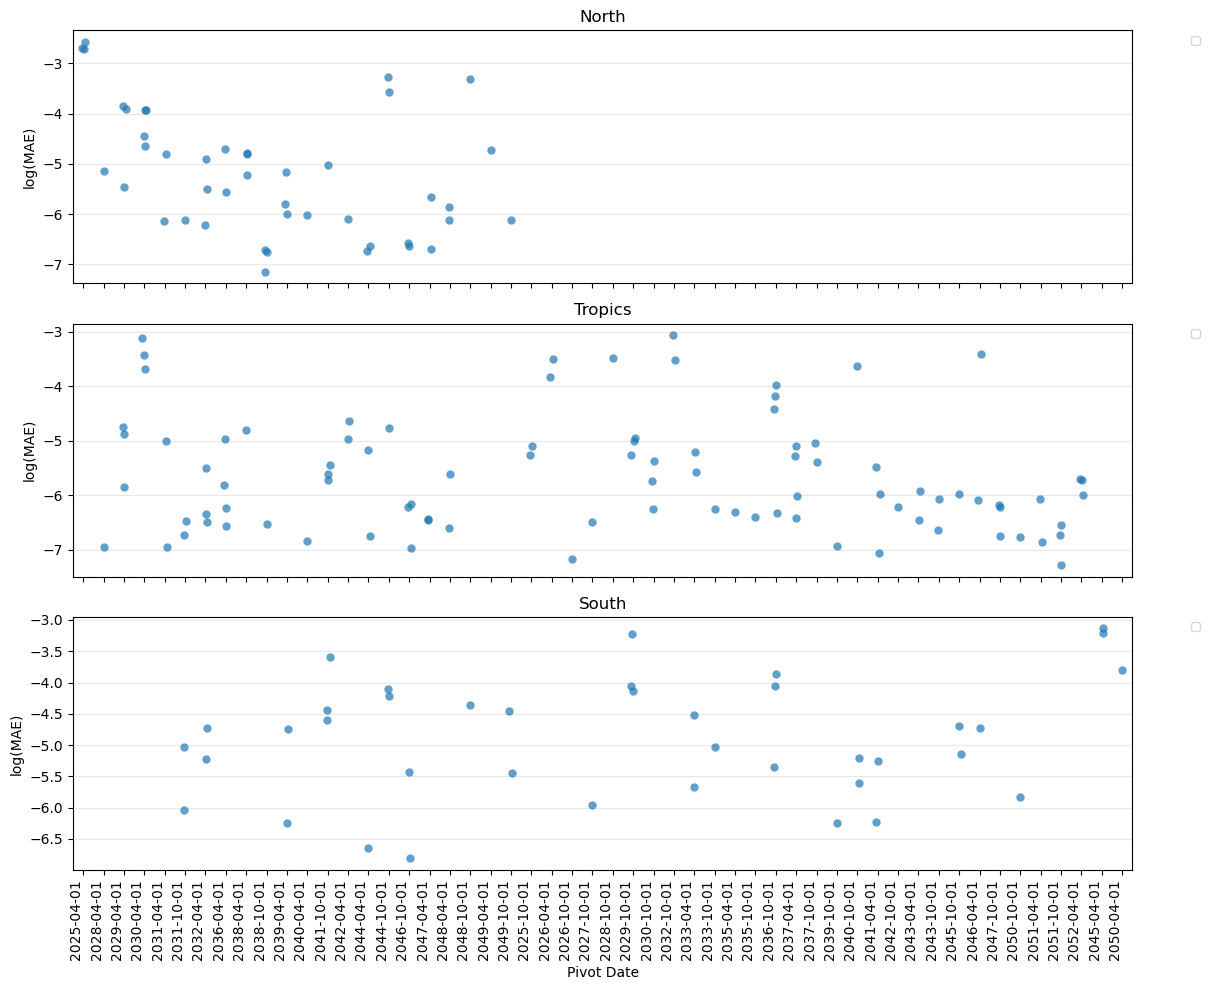

In [21]:
# Filter for GARW only -- look at log scale.
garw_df = variant_growth_rate_errors_df[variant_growth_rate_errors_df['model'] == 'GARW']

# Create 3x1 subplots
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

locations = ['north', 'tropics', 'south']

for ax, location in zip(axes, locations):
    # Filter for location
    loc_df = garw_df[garw_df['location'] == location]
    
    # Stripplot with jitter
    sns.stripplot(data=loc_df, x='pivot_date', y='log_mae', ax=ax, alpha=0.7, s=6, jitter=True)
    
    ax.set_ylabel('log(MAE)')
    ax.set_xlabel('')
    ax.set_title(f'{location.capitalize()}')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')

axes[-1].set_xlabel('Pivot Date')
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()

In [22]:
# Grab all rows with log_MAE > error_threshold
error_threshold = -4
filtered_errors_df = variant_growth_rate_errors_df[variant_growth_rate_errors_df['log_mae'] > error_threshold]
filtered_errors_df.head()

,variant,pivot_date,model,location,mae,mse,normalized_mae,max_r_data,correlation,r2,n_points,total_sequences,total_smoothed_sequences,mean_variant_frequency,mean_smoothed_variant_frequency,max_variant_frequency,max_smoothed_variant_frequency,converged,log_mae,log_mse
31,12,2036-10-01,FGA,north,0.027256,0.001135,0.375272,0.072630,0.992055,0.476533,21,2834.0,2833.960031,0.549126,0.548792,0.890909,0.868620,True,-3.602450,-6.780314
32,14,2036-10-01,FGA,north,0.041006,0.002385,0.493803,0.083042,0.992185,0.063259,20,3058.0,3058.063609,0.592460,0.563453,0.934783,0.887182,True,-3.194005,-6.037993
64,25,2048-10-01,FGA,north,0.038748,0.002610,0.856919,0.045218,-0.540942,-1.780908,27,1324.0,1323.980568,0.992973,0.993070,1.000000,0.996711,True,-3.250658,-5.947850
79,4,2030-04-01,FGA,south,0.068265,0.004878,1.154806,0.059114,0.974445,-2.032695,5,73.0,72.736400,0.023175,0.041090,0.033333,0.050625,True,-2.684346,-5.322834
80,5,2030-04-01,FGA,south,0.045327,0.002523,0.601088,0.075408,0.886116,-0.255104,17,749.0,748.918484,0.213955,0.216022,0.666667,0.474716,True,-3.093836,-5.981937


In [23]:
low_bound = -6
upper_bound = -5
intermediate_errors_df = variant_growth_rate_errors_df[(variant_growth_rate_errors_df['log_mae'] >= low_bound) & (variant_growth_rate_errors_df['log_mae'] <= upper_bound)]
intermediate_errors_df.head()

,variant,pivot_date,model,location,mae,mse,normalized_mae,max_r_data,correlation,r2,n_points,total_sequences,total_smoothed_sequences,mean_variant_frequency,mean_smoothed_variant_frequency,max_variant_frequency,max_smoothed_variant_frequency,converged,log_mae,log_mse
22,8,2031-10-01,FGA,north,0.003757,0.000019,0.100587,0.037351,0.985855,0.952583,19,424.0,424.041869,0.993016,0.983148,1.000000,1.000000,True,-5.583856,-10.839003
24,9,2032-04-01,FGA,north,0.005151,0.000036,0.070939,0.072614,0.995720,0.988502,23,6146.0,6146.000543,0.905661,0.895988,1.000000,0.984318,True,-5.268342,-10.197249
25,10,2032-04-01,FGA,north,0.006451,0.000064,0.071214,0.090588,0.989602,0.964926,10,250.0,250.051698,0.077043,0.081621,0.182353,0.152248,True,-5.043347,-9.643961
36,16,2038-04-01,FGA,north,0.006650,0.000072,0.150056,0.044316,0.997019,-0.033152,7,146.0,145.890565,0.247167,0.253397,0.327103,0.309695,True,-5.013004,-9.526139
49,18,2041-10-01,FGA,north,0.005428,0.000041,0.093002,0.058368,0.997020,0.975872,26,2818.0,2817.767385,0.953833,0.934534,1.000000,0.992277,True,-5.215943,-10.075533


In [24]:
len(filtered_errors_df.query('location == "north"'))

13

## Northern deme zoom-in variants of interest

In [25]:
intermediate_errors_df.query('location == "north" and model == "GARW"')

,variant,pivot_date,model,location,mae,mse,normalized_mae,max_r_data,correlation,r2,n_points,total_sequences,total_smoothed_sequences,mean_variant_frequency,mean_smoothed_variant_frequency,max_variant_frequency,max_smoothed_variant_frequency,converged,log_mae,log_mse
238,3,2028-04-01,GARW,north,0.005832,0.000046,0.193617,0.030119,0.989057,0.614962,14,581.0,581.033568,0.996763,0.997034,1.000000,0.998409,True,-5.144305,-9.956696
240,3,2029-04-01,GARW,north,0.004262,0.000025,0.116961,0.036440,0.947716,0.364524,8,232.0,231.870830,1.000000,0.963174,1.000000,0.987087,True,-5.457768,-10.547881
256,9,2032-04-01,GARW,north,0.004098,0.000022,0.056440,0.072614,0.996499,0.992877,23,6146.0,6146.000543,0.905661,0.895988,1.000000,0.984318,True,-5.496934,-10.659716
262,14,2036-04-01,GARW,north,0.003858,0.000036,0.042743,0.090264,0.998885,0.971118,12,2507.0,2507.030604,0.442135,0.442519,0.736364,0.869948,True,-5.557313,-10.192163
268,16,2038-04-01,GARW,north,0.005361,0.000046,0.120965,0.044316,0.997532,0.342770,7,146.0,145.890565,0.247167,0.253397,0.327103,0.309695,True,-5.228481,-9.970661
273,15,2039-04-01,GARW,north,0.003002,0.000011,0.084035,0.035721,0.977393,0.550752,5,85.0,84.909892,0.224993,0.233851,0.256757,0.269399,True,-5.808189,-11.338084
274,16,2039-04-01,GARW,north,0.005740,0.000046,0.199796,0.028728,0.826291,0.152322,9,172.0,171.957869,0.280201,0.269819,0.392405,0.354584,True,-5.160161,-9.968072
281,18,2041-10-01,GARW,north,0.006550,0.000062,0.112220,0.058368,0.998920,0.963862,26,2818.0,2817.767385,0.953833,0.934534,1.000000,0.992277,True,-5.028135,-9.679502
291,23,2047-04-01,GARW,north,0.003473,0.000014,0.088121,0.039415,0.979777,0.736840,7,169.0,169.005513,0.272787,0.296303,0.414414,0.369860,True,-5.662369,-11.104029
294,24,2048-04-01,GARW,north,0.002822,0.000010,0.064561,0.043717,0.967269,0.508898,7,179.0,178.920235,0.861266,0.866031,0.923077,0.893547,True,-5.869808,-11.457268


In [26]:
filtered_errors_df.query('location == "north" and model == "GARW"')

,variant,pivot_date,model,location,mae,mse,normalized_mae,max_r_data,correlation,r2,n_points,total_sequences,total_smoothed_sequences,mean_variant_frequency,mean_smoothed_variant_frequency,max_variant_frequency,max_smoothed_variant_frequency,converged,log_mae,log_mse
232,0,2025-04-01,GARW,north,0.076404,0.007038,0.905379,0.084389,-0.393941,-12.546393,8,414.0,413.824772,0.135844,0.141616,0.193959,0.242101,True,-2.571701,-4.956221
233,1,2025-04-01,GARW,north,0.065877,0.005468,0.901162,0.073102,0.101977,-11.657443,11,1956.0,1955.842521,0.639951,0.637443,0.732601,0.696702,True,-2.719958,-5.208683
234,2,2025-04-01,GARW,north,0.067625,0.005887,1.389886,0.048655,0.149458,-7.874718,11,459.0,458.851073,0.239275,0.236174,0.466667,0.404918,True,-2.693769,-5.134762
241,4,2029-04-01,GARW,north,0.021493,0.000668,0.349539,0.061489,0.773544,-0.114991,9,154.0,154.137380,0.138062,0.141454,0.205128,0.177717,True,-3.839985,-7.309771
242,5,2029-04-01,GARW,north,0.019940,0.000733,0.189413,0.105275,0.533536,0.077105,13,1093.0,1093.005428,0.829609,0.827287,0.933333,0.901526,True,-3.914955,-7.217628
246,4,2030-04-01,GARW,north,0.019475,0.000493,0.570781,0.034120,-0.819487,-3.983590,5,69.0,68.893848,0.124251,0.114199,0.162500,0.116178,True,-3.938579,-7.612338
247,5,2030-04-01,GARW,north,0.019785,0.000517,0.392790,0.050369,0.602109,-1.415648,11,699.0,699.007946,0.863788,0.766933,0.936170,0.882162,True,-3.922802,-7.565752
285,21,2044-10-01,GARW,north,0.027895,0.002018,0.452010,0.061714,0.197779,-0.287866,27,3504.0,3504.068611,0.890968,0.887022,1.000000,0.968733,True,-3.579267,-6.205085
286,22,2044-10-01,GARW,north,0.037930,0.002387,0.481110,0.078839,-0.165239,-0.650377,15,378.0,377.716475,0.146605,0.133773,0.375000,0.288231,True,-3.271986,-6.037338
296,25,2048-10-01,GARW,north,0.036655,0.002271,0.810636,0.045218,-0.500453,-1.418845,27,1324.0,1323.980568,0.992973,0.993070,1.000000,0.996711,True,-3.306180,-6.087280


In [27]:
filtered_errors_df.query('location == "north" and model == "FGA"')

,variant,pivot_date,model,location,mae,mse,normalized_mae,max_r_data,correlation,r2,n_points,total_sequences,total_smoothed_sequences,mean_variant_frequency,mean_smoothed_variant_frequency,max_variant_frequency,max_smoothed_variant_frequency,converged,log_mae,log_mse
31,12,2036-10-01,FGA,north,0.027256,0.001135,0.375272,0.072630,0.992055,0.476533,21,2834.0,2833.960031,0.549126,0.548792,0.890909,0.868620,True,-3.602450,-6.780314
32,14,2036-10-01,FGA,north,0.041006,0.002385,0.493803,0.083042,0.992185,0.063259,20,3058.0,3058.063609,0.592460,0.563453,0.934783,0.887182,True,-3.194005,-6.037993
64,25,2048-10-01,FGA,north,0.038748,0.002610,0.856919,0.045218,-0.540942,-1.780908,27,1324.0,1323.980568,0.992973,0.993070,1.000000,0.996711,True,-3.250658,-5.947850


## Tropics deme zoom-in variants of interest

In [28]:
filtered_errors_df.query('location == "tropics" and model == "GARW"')

,variant,pivot_date,model,location,mae,mse,normalized_mae,max_r_data,correlation,r2,n_points,total_sequences,total_smoothed_sequences,mean_variant_frequency,mean_smoothed_variant_frequency,max_variant_frequency,max_smoothed_variant_frequency,converged,log_mae,log_mse
370,1,2026-04-01,GARW,tropics,0.021628,0.000468,2.982941,0.007251,NaN,NaN,1,11.0,10.801691,0.611111,0.440506,0.611111,0.440506,True,-3.833709,-7.665376
371,2,2026-04-01,GARW,tropics,0.030137,0.002492,1.379413,0.021848,-0.404752,-12.288296,44,2193.0,2192.924094,0.955688,0.944766,1.000000,1.000000,True,-3.501954,-5.994312
375,3,2028-10-01,GARW,tropics,0.030958,0.003258,1.638009,0.018900,-0.459444,-87.008421,43,1338.0,1337.873326,0.948856,0.939917,1.000000,1.000000,True,-3.475077,-5.726474
382,4,2030-04-01,GARW,tropics,0.025017,0.001066,4.343341,0.005760,0.350563,-419.706636,10,136.0,135.563674,0.119382,0.110205,0.200000,0.173128,True,-3.688144,-6.842449
383,5,2030-04-01,GARW,tropics,0.044849,0.003348,1.249726,0.035887,0.856858,-37.453302,17,559.0,558.969313,0.280772,0.280287,0.675000,0.619442,True,-3.104439,-5.699229
384,6,2030-04-01,GARW,tropics,0.032358,0.002153,0.462483,0.069966,0.429970,-1.999726,37,3528.0,3528.010432,0.821005,0.818296,1.000000,0.996590,True,-3.430862,-6.140210
395,9,2032-10-01,GARW,tropics,0.029569,0.001800,0.776406,0.038084,-0.833381,-3.493693,36,2077.0,2076.937997,0.642110,0.645251,1.000000,0.980658,True,-3.521007,-6.319517
396,10,2032-10-01,GARW,tropics,0.046981,0.002939,0.953522,0.049271,-0.109390,-6.238068,33,2404.0,2404.168164,0.601288,0.604819,0.950820,0.910499,True,-3.057996,-5.829491
409,14,2036-10-01,GARW,tropics,0.018685,0.000423,0.454398,0.041121,0.930527,-0.880146,29,1205.0,1204.934427,0.467021,0.469770,0.864407,0.825444,True,-3.979963,-7.764680
420,17,2040-10-01,GARW,tropics,0.026564,0.002050,3.512210,0.007563,-0.315161,-232.485542,49,1108.0,1108.008952,0.907351,0.906249,1.000000,0.946504,True,-3.628159,-6.189594


In [29]:
filtered_errors_df.query('location == "tropics" and model == "FGA"')

,variant,pivot_date,model,location,mae,mse,normalized_mae,max_r_data,correlation,r2,n_points,total_sequences,total_smoothed_sequences,mean_variant_frequency,mean_smoothed_variant_frequency,max_variant_frequency,max_smoothed_variant_frequency,converged,log_mae,log_mse


## Southern deme zoom-in variants of interest

In [30]:
filtered_errors_df.query('location == "south" and model == "GARW"')

,variant,pivot_date,model,location,mae,mse,normalized_mae,max_r_data,correlation,r2,n_points,total_sequences,total_smoothed_sequences,mean_variant_frequency,mean_smoothed_variant_frequency,max_variant_frequency,max_smoothed_variant_frequency,converged,log_mae,log_mse
308,4,2029-10-01,GARW,south,0.040084,0.001746,0.495016,0.080975,0.990342,0.403487,5,73.0,72.492613,0.023175,0.076057,0.033333,0.091298,True,-3.216756,-6.349694
329,14,2036-10-01,GARW,south,0.020838,0.000543,0.312865,0.066604,0.991025,0.761931,25,6150.0,6150.015080,0.833186,0.820788,0.946809,0.945632,True,-3.870932,-7.516676
343,20,2041-10-01,GARW,south,0.027375,0.001017,0.606774,0.045115,0.999399,-1.230624,9,187.0,186.855192,0.114629,0.114032,0.223529,0.173406,True,-3.598102,-6.890366
350,21,2045-04-01,GARW,south,0.040634,0.002114,1.608698,0.025259,0.226311,-5.448884,16,253.0,252.659801,0.322377,0.297887,0.800000,0.559206,True,-3.203127,-6.158594
351,22,2045-04-01,GARW,south,0.043525,0.002586,1.006654,0.043237,-0.231703,-2.041884,24,1211.0,1210.994126,0.803132,0.787581,1.000000,0.909282,True,-3.134403,-5.957142
362,26,2050-04-01,GARW,south,0.022391,0.000742,0.806610,0.027759,-0.154168,-2.098128,14,213.0,212.879619,0.853131,0.842379,0.928571,0.903384,True,-3.799063,-7.205396


In [31]:
filtered_errors_df.query('location == "south" and model == "FGA"')

,variant,pivot_date,model,location,mae,mse,normalized_mae,max_r_data,correlation,r2,n_points,total_sequences,total_smoothed_sequences,mean_variant_frequency,mean_smoothed_variant_frequency,max_variant_frequency,max_smoothed_variant_frequency,converged,log_mae,log_mse
79,4,2030-04-01,FGA,south,0.068265,0.004878,1.154806,0.059114,0.974445,-2.032695,5,73.0,72.736400,0.023175,0.041090,0.033333,0.050625,True,-2.684346,-5.322834
80,5,2030-04-01,FGA,south,0.045327,0.002523,0.601088,0.075408,0.886116,-0.255104,17,749.0,748.918484,0.213955,0.216022,0.666667,0.474716,True,-3.093836,-5.981937
81,6,2030-04-01,FGA,south,0.038551,0.001968,0.484829,0.079514,0.944797,0.452015,20,6336.0,6336.062345,0.824780,0.797012,0.941915,0.950025,True,-3.255750,-6.230033
97,14,2036-10-01,FGA,south,0.020724,0.000566,0.311149,0.066604,0.993260,0.751986,25,6150.0,6150.015080,0.833186,0.820788,0.946809,0.945632,True,-3.876432,-7.475827
130,26,2050-04-01,FGA,south,0.023793,0.000820,0.857126,0.027759,-0.220475,-2.423848,14,213.0,212.879619,0.853131,0.842379,0.928571,0.903384,True,-3.738321,-7.105558
